# 05 · Mỗi phòng ban nhận được gì

Notebook này kiểm chứng từng dòng của bảng "trước / sau khi có hệ thống" bằng số liệu thật, và nói rõ **mức độ tin cậy** của từng phần.

| Phòng ban | Trước đây | Sau khi có hệ thống | Code |
|---|---|---|---|
| **Ban lãnh đạo** | Đọc nhiều báo cáo rời rạc | Bản tin tóm tắt hằng tuần + dashboard **6 nhóm KPI** (đúng slide "Kế hoạch đo lường KPI") | `src/kpis.py` |
| **Marketing** | Phát voucher đại trà | Phân nhóm khách theo slide "Phân nhóm khách hàng & chiến lược giữ chân" + **điểm khả năng quay lại** + biết **campaign nào chỉ hút khách một lần** | `src/marketing.py` |
| **CSKH** | Gặp lỗi mới đi hỏi IT | Cảnh báo sớm + danh sách cứu đơn + **mẫu trả lời theo mã lỗi** | `src/pipeline.py`, `src/briefs.py` |
| **Product / IT** | Chờ khách phàn nàn mới biết | Cảnh báo tuần: **mã lỗi nào, nền tảng nào, phương thức nào, tăng bao nhiêu** | `src/anomaly.py`, `src/product.py` |
| **Tài chính** | Không biết lỗi thanh toán làm mất bao nhiêu | Giá trị **đơn lỗi không được mua lại** + **tiền giảm giá cho khách chỉ mua một lần** | `src/finance.py` |

Ví dụ xuyên suốt: tuần **28/02/2022** (tuần có đợt lỗi ngân hàng).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # để import được thư mục src/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
BLUE, RED, GREY = "#2f6db5", "#d1495b", "#9aa5b1"

In [2]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")
os.environ.setdefault("LLM_MODE", "off")
from IPython.display import Markdown
from src.data_prep import load_tickets
from src import anomaly, briefs, departments, finance, kpis, marketing, metrics, pipeline

df = load_tickets()
WEEK = "2022-02-28"
extra, tables = departments.build(df, WEEK)

## 1. Ban lãnh đạo — dashboard 6 nhóm KPI
Định nghĩa theo slide (dữ liệu không có lượt truy cập, nên "chuyển đổi" tính ở mức khách: khách có thanh toán trong tháng → bao nhiêu % mua thành công):

In [3]:
pd.DataFrame(kpis.KPI_DEFINITIONS, columns=["nhóm KPI", "mã", "chỉ số", "định dạng", "chiều tốt (+1 tăng / -1 giảm)"])

,nhóm KPI,mã,chỉ số,định dạng,chiều tốt (+1 tăng / -1 giảm)
0,1. Tăng số giao dịch thành công,success_tickets,Vé đặt thành công,int,1
1,1. Tăng số giao dịch thành công,conversion,Tỷ lệ chuyển đổi (khách),pct,1
2,1. Tăng số giao dịch thành công,revenue,Doanh thu,money,1
3,2. Tăng tỷ lệ khách quay lại,repeat_90d,Khách mới mua lần 2 trong 90 ngày,pct,1
4,2. Tăng tỷ lệ khách quay lại,retention_30d,Giữ chân sau 30 ngày,pct,1
5,3. Giảm phụ thuộc khuyến mãi,repeat_no_promo_share,Mua lại không dùng khuyến mãi,pct,1
6,3. Giảm phụ thuộc khuyến mãi,discount_per_retained,Chi phí giảm giá / 1 khách KM quay lại,money,-1
7,4. Cải thiện thanh toán,payment_success_rate,Tỷ lệ thanh toán thành công,pct,1
8,4. Cải thiện thanh toán,payment_failure_rate,Tỷ lệ lỗi thanh toán,pct,-1
9,5. Tối ưu mobile,mobile_conversion,Tỷ lệ chuyển đổi trên mobile,pct,1


In [4]:
kpi_all = kpis.monthly_kpis(df)
kpi_2022 = kpi_all.loc["2022-01":"2022-12"]
show = {key: label for _, key, label, _, _ in kpis.KPI_DEFINITIONS}
kpi_2022[list(show)].rename(columns=show).T.round(3)

year_month,2022-01,2022-02,2022-03,2022-04,2022-05,2022-06,2022-07,2022-08,2022-09,2022-10,2022-11,2022-12
Vé đặt thành công,479.000,3463.000,3884.000,4603.000,11365.000,7430.000,15613.000,5046.000,7205.000,8923.000,7571.000,8118.000
Tỷ lệ chuyển đổi (khách),0.873,0.839,0.838,0.859,0.873,0.869,0.891,0.920,0.922,0.917,0.920,0.931
Doanh thu,3988.260,27702.360,29177.850,36934.430,85733.120,59906.760,118733.060,37666.700,59043.680,64596.910,53610.370,76202.560
Khách mới mua lần 2 trong 90 ngày,0.107,0.096,0.086,0.111,0.098,0.085,0.070,0.103,0.078,NaN,NaN,NaN
Giữ chân sau 30 ngày,0.045,0.039,0.034,0.048,0.040,0.047,0.033,0.045,0.030,0.031,0.025,NaN
Mua lại không dùng khuyến mãi,0.467,0.473,0.365,0.387,0.298,0.461,0.451,0.585,0.645,0.645,0.432,0.548
Chi phí giảm giá / 1 khách KM quay lại,30.399,33.125,36.040,26.171,33.053,40.416,27.342,15.750,23.155,NaN,NaN,NaN
Tỷ lệ thanh toán thành công,0.849,0.823,0.824,0.852,0.860,0.860,0.880,0.912,0.916,0.910,0.914,0.925
Tỷ lệ lỗi thanh toán,0.151,0.177,0.176,0.148,0.140,0.140,0.120,0.088,0.084,0.090,0.086,0.075
Tỷ lệ chuyển đổi trên mobile,0.869,0.838,0.837,0.857,0.874,0.868,0.891,0.920,0.925,0.918,0.921,0.935


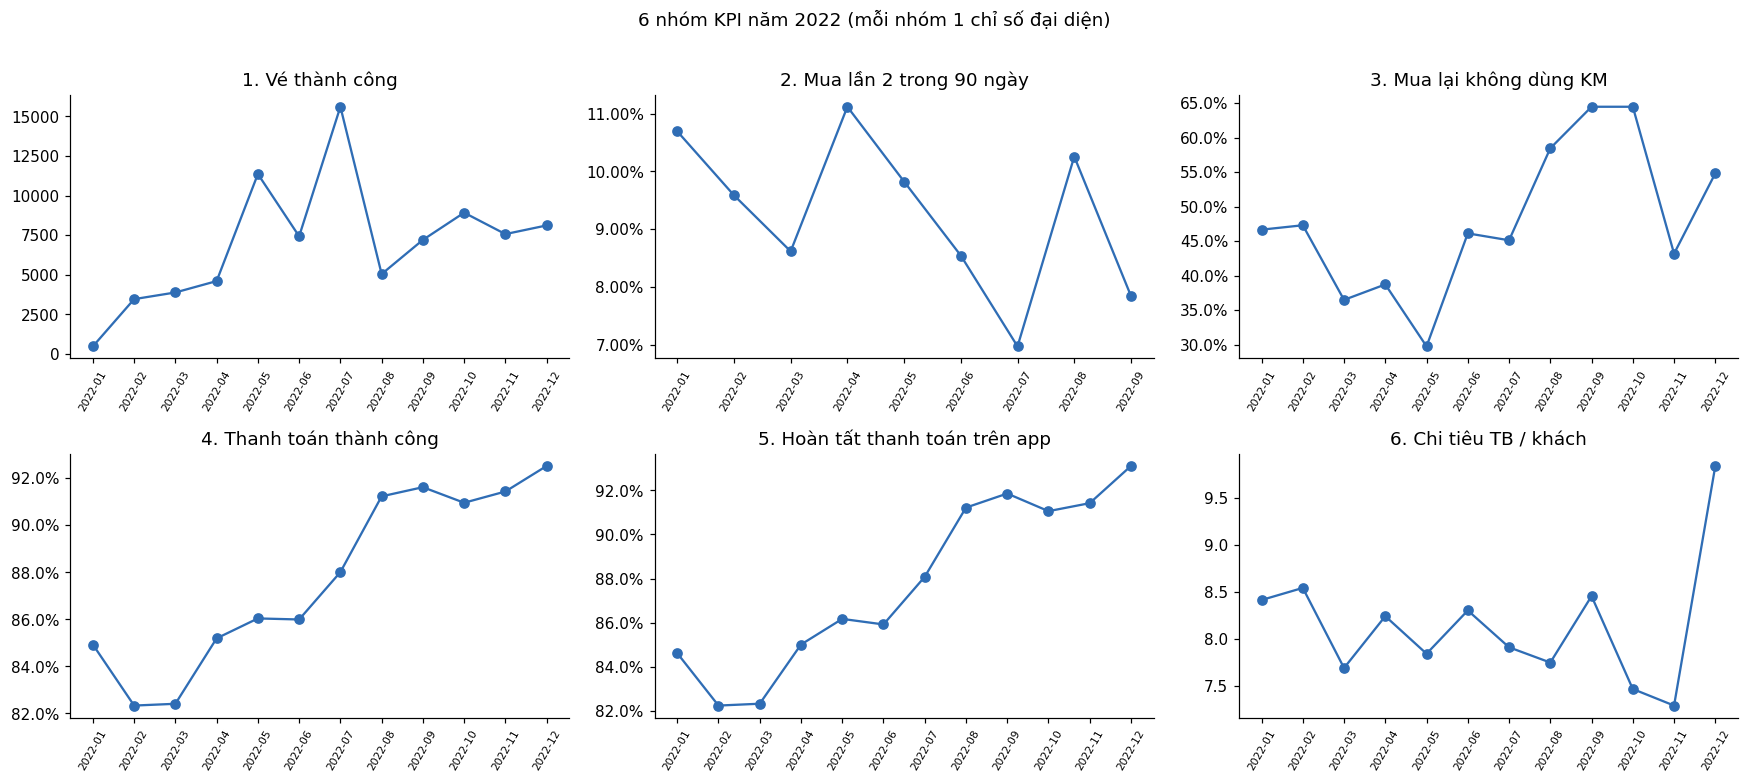

In [5]:
picks = [("success_tickets", "1. Vé thành công"), ("repeat_90d", "2. Mua lần 2 trong 90 ngày"),
         ("repeat_no_promo_share", "3. Mua lại không dùng KM"), ("payment_success_rate", "4. Thanh toán thành công"),
         ("app_completion_rate", "5. Hoàn tất thanh toán trên app"), ("spend_per_customer", "6. Chi tiêu TB / khách")]
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax, (key, title) in zip(axes.flat, picks):
    ax.plot(kpi_2022.index, kpi_2022[key], marker="o", color=BLUE)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=60, labelsize=7)
    if kpi_2022[key].max() <= 1:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
plt.suptitle("6 nhóm KPI năm 2022 (mỗi nhóm 1 chỉ số đại diện)", y=1.01)
plt.tight_layout()

In [6]:
alerts = anomaly.detect(metrics.weekly_error_rates(df))
facts = {**briefs.weekly_facts(df, alerts, WEEK), **extra}
brief, source = briefs.generate_brief(facts, "leadership")
Markdown(briefs.to_markdown(brief, "leadership", facts, source))

# Ban lãnh đạo - tuần 2022-02-28 → 2022-03-06
_Nguồn: template (LLM_MODE=off)_

## Tóm tắt tuần 2022-02-28 · KPI tháng 2022-02

1,019 lượt thanh toán, tỷ lệ thành công 80.8% (8 tuần trước: 82.4%). CẢNH BÁO: lỗi phía ngân hàng 17.8% (mức nền 8.7%, z = 5.0).

### Điểm chính
- 1,019 lượt thanh toán, tỷ lệ thành công 80.8% (8 tuần trước: 82.4%).
- CẢNH BÁO: lỗi phía ngân hàng 17.8% (mức nền 8.7%, z = 5.0).
- 1. Tăng số giao dịch thành công: Vé đặt thành công 3,463 (tháng trước 479); Tỷ lệ chuyển đổi (khách) 83.9% (tháng trước 87.3%); Doanh thu 27,702 (tháng trước 3,988)
- 2. Tăng tỷ lệ khách quay lại: Khách mới mua lần 2 trong 90 ngày n/a (tháng trước n/a); Giữ chân sau 30 ngày n/a (tháng trước 4.5%)
- 3. Giảm phụ thuộc khuyến mãi: Mua lại không dùng khuyến mãi 47.3% (tháng trước 46.7%); Chi phí giảm giá / 1 khách KM quay lại n/a (tháng trước n/a)
- 4. Cải thiện thanh toán: Tỷ lệ thanh toán thành công 82.3% (tháng trước 84.9%); Tỷ lệ lỗi thanh toán 17.7% (tháng trước 15.1%)
- 5. Tối ưu mobile: Tỷ lệ chuyển đổi trên mobile 83.8% (tháng trước 86.9%); Tỷ lệ hoàn tất thanh toán trên app 82.3% (tháng trước 84.6%)
- 6. Nâng cao giá trị khách hàng: Tần suất mua (vé / khách) 1.07 (tháng trước 1.01); Chi tiêu TB / khách 8.54 (tháng trước 8.41); Giá trị tích lũy TB / khách 9.61 (tháng trước 9.59)
- Campaign kém hiệu quả nhất về giữ chân: 'reward point'.

### Hành động đề xuất
| Việc cần làm | Phụ trách | Chỉ số theo dõi |
|---|---|---|
| Duyệt chiến dịch cứu đơn tự động cho mọi giao dịch lỗi | Ban lãnh đạo | Tỷ lệ thanh toán thành công |
| Chuyển ngân sách khuyến mãi sang loại campaign giữ chân tốt hơn | Ban lãnh đạo + Marketing | Khách mới mua lần 2 trong 90 ngày |


## 2. Marketing
### 2a. Phân nhóm khách — luật lấy đúng từ slide của báo cáo
Thứ tự ưu tiên: giá trị cao (≥ 3 lần mua và còn hoạt động trong 180 ngày) → mua một lần & mới (≤ 30 ngày) → lâu chưa quay lại (> 90 ngày) → nhạy khuyến mãi (≥ 50% giao dịch có KM) → thường xuyên.

In [7]:
targets = tables["marketing_targets"]
seg = targets.groupby("segment").agg(customers=("score", "size"), avg_score=("score", "mean"),
                                     avg_frequency=("frequency", "mean"), avg_recency_days=("recency_days", "mean"))
seg["action"] = seg.index.map(marketing.SEGMENT_ACTIONS)
seg.sort_values("customers", ascending=False).round(3)

,customers,avg_score,avg_frequency,avg_recency_days,action
segment,,,,,
Khách lâu chưa quay lại,37940,0.013,1.244,774.822,"Kéo lại bằng phim mới, voucher quay lại, thông..."
Khách mua một lần (mới),3145,0.016,1.000,15.810,Tặng coupon cho lần mua thứ hai trong vòng 7–1...
Khách nhạy khuyến mãi,1425,0.039,1.321,52.472,"Chuyển từ giảm giá trực tiếp sang tích điểm, v..."
Khách thường xuyên,557,0.030,1.214,59.259,"Duy trì, không cần giảm giá sâu"
Khách giá trị cao,333,0.094,5.402,33.679,"Membership, ưu đãi đặc quyền, đặt vé sớm phim hot"


### 2b. Điểm khả năng quay lại trong 90 ngày — có đáng tin không?
Backtest: train trên 3 mốc (01/03, 01/04, 01/05/2022 — nhãn = có mua trong 90 ngày sau mốc), test trên mốc **01/08/2022** (chưa từng thấy).
So với luật đơn giản "mua gần đây nhất = điểm cao nhất".

In [8]:
train = marketing.training_set(df, ["2022-03-01", "2022-04-01", "2022-05-01"])
test = marketing.training_set(df, ["2022-08-01"])
propensity = marketing.train_propensity(train)
evaluation = marketing.evaluate_propensity(propensity, test)
pd.Series(evaluation).round(3).to_frame("giá trị")

,giá trị
AUC model,0.657
AUC rule: recency,0.613
base rate,0.048
precision top 20%,0.085
capture top 20%,0.358


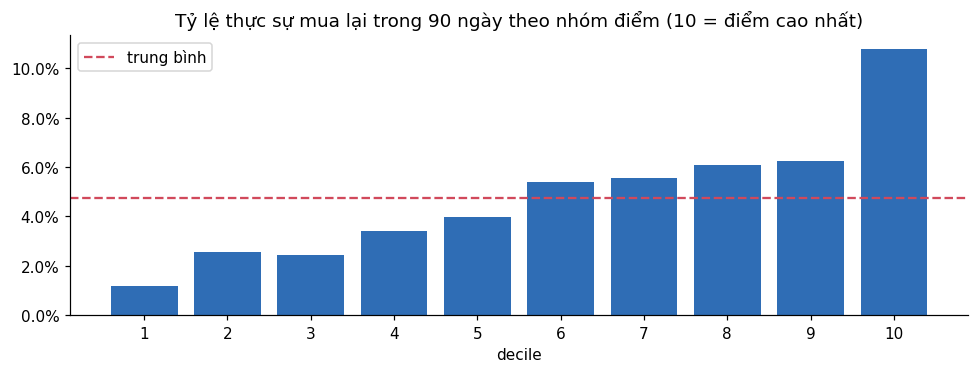

In [9]:
test_scored = test.assign(score=propensity.predict_proba(test[marketing.FEATURES])[:, 1])
test_scored["decile"] = pd.qcut(test_scored["score"].rank(method="first"), 10, labels=range(1, 11))
lift = test_scored.groupby("decile", observed=True)["y"].mean()
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(lift.index.astype(str), lift, color=BLUE)
ax.axhline(test["y"].mean(), color=RED, ls="--", label="trung bình")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set(title="Tỷ lệ thực sự mua lại trong 90 ngày theo nhóm điểm (10 = điểm cao nhất)", xlabel="decile")
ax.legend()
plt.tight_layout()

**Đọc trung thực:** model tốt hơn luật recency nhưng **tín hiệu vừa phải** (AUC ~0.66). Giá trị thực tế: nhóm điểm cao nhất mua lại nhiều hơn hẳn trung bình, nên Marketing **ưu tiên ngân sách** cho nhóm này thay vì phát voucher đại trà. Không nên hứa "biết chắc ai sẽ quay lại".

Khác với model ở notebook 03 (AUC 0.53 — chỉ dùng thông tin lần mua đầu): ở đây dùng **lịch sử mua** (recency, frequency, monetary…), và chính recency/frequency mang tín hiệu.

### 2c. Campaign nào chỉ hút khách một lần?
Khách mới đến từ mỗi loại campaign (lần mua đầu), tỷ lệ mua lần 2 trong 90 ngày, và **tiền giảm giá cho mỗi khách thực sự quay lại**:

In [10]:
tables["campaign_effectiveness"].round(3)

,new_customers,returned_90d,discount_spend,n_returned,one_time_rate,discount_per_returned
campaign_type,,,,,,
reward point,3148,0.043,17204.08,136,0.957,126.501
direct discount,17373,0.083,55619.03,1448,0.917,38.411
none,16985,0.103,0.00,1748,0.897,0.000
voucher,1184,0.111,1626.35,132,0.889,12.321


In [11]:
tables_full = departments.build(df, "2022-12-19")[1]
print("Dữ liệu tới hết 2022:")
display(tables_full["campaign_effectiveness"].round(3))
tables_full["campaign_ids"].head(8).round(3)

Dữ liệu tới hết 2022:


,new_customers,returned_90d,discount_spend,n_returned,one_time_rate,discount_per_returned
campaign_type,,,,,,
reward point,3148,0.043,17204.08,136,0.957,126.501
direct discount,46150,0.083,136827.01,3821,0.917,35.809
none,31884,0.096,6848.54,3056,0.904,2.241
voucher,5284,0.115,7248.25,606,0.885,11.961


,new_customers,returned_90d,discount_spend,n_returned,one_time_rate,discount_per_returned
campaign_id,,,,,,
13740,691,0.007,7265.07,5,0.993,1453.014
41330,1155,0.028,4840.36,32,0.972,151.261
19800,2565,0.035,13911.47,89,0.965,156.309
17190,2457,0.053,9939.01,131,0.947,75.870
41300,4724,0.060,13447.37,284,0.940,47.350
74430,536,0.062,664.64,33,0.938,20.141
85940,1338,0.067,1378.14,90,0.933,15.313
82990,871,0.071,3849.54,62,0.929,62.089


- **reward point** gần như chỉ hút khách một lần, và tốn nhiều giảm giá nhất cho mỗi khách quay lại; **voucher** giữ chân tốt nhất trong các loại khuyến mãi.
- Khách **không dùng khuyến mãi** (`none`) quay lại ngang hoặc hơn khách đến từ direct discount → khớp kết luận ở notebook 01: khuyến mãi kéo khách mới nhưng không tạo thói quen.
- Ở mức từng campaign, có những campaign gần như **không giữ được ai** → ứng viên đầu tiên để cắt ngân sách.

⚠️ So sánh này là quan sát, chưa phải nhân quả (mỗi loại campaign có thể nhắm tệp khách khác nhau).

## 3. CSKH — cảnh báo sớm + mẫu trả lời theo mã lỗi

In [12]:
recovery = pipeline.recovery_list(df, pd.Timestamp(WEEK))
print(f"Tuần {WEEK}: {len(recovery)} khách cần liên hệ lại")
display(pd.Series(extra["customer_care"]["errors_by_code"], name="số lỗi trong tuần"))
pd.Series(briefs.RECOVERY_MESSAGES, name="mẫu tin nhắn").rename_axis("status_id").to_frame()

Tuần 2022-02-28: 175 khách cần liên hệ lại


Payment failed from bank                                                                        180
Need verify your account to continue                                                              7
Transaction temporarily limited                                                                   3
Payment overdue                                                                                   3
Insufficient funds in customer account. Please add more funds and try the transaction again.      2
No response from your bank                                                                        1
Name: số lỗi trong tuần, dtype: object

,mẫu tin nhắn
status_id,
-1,Đơn đặt vé của bạn đã quá hạn thanh toán. Ghế ...
-2,Tài khoản chưa đủ số dư nên giao dịch chưa thà...
-3,Ngân hàng chưa phản hồi nên vé chưa được xuất....
-4,Tài khoản thanh toán bị khóa tạm do nhập sai m...
-5,Thanh toán qua ngân hàng chưa thành công (lỗi ...
-6,Bạn cần xác minh tài khoản để tiếp tục thanh t...
-7,Giao dịch đang bị giới hạn tạm thời. Đội hỗ tr...


## 4. Product / IT — mã lỗi nào, nền tảng nào, tăng bao nhiêu
Cảnh báo theo nhóm lỗi (notebook 04) cho biết **có sự cố**; bảng dưới khoanh vùng **ở đâu**: tỷ lệ lỗi của từng tổ hợp mã lỗi × nền tảng × phương thức tuần này so với 8 tuần trước.

In [13]:
tables["product_breakdown"].head(10).round(3)

,description,platform,paying_method,errors,attempts,rate,baseline_rate,change_pp,excess_errors
0,Payment failed from bank,mobile,bank account,95,450,0.211,0.046,16.517,74.326
1,Payment failed from bank,mobile,debit card,57,156,0.365,0.196,16.916,26.389
2,Payment failed from bank,mobile,credit card,23,94,0.245,0.215,2.930,2.754
3,Payment overdue,mobile,credit card,2,94,0.021,0.003,1.820,1.711
4,Transaction temporarily limited,mobile,bank account,2,450,0.004,0.001,0.347,1.560
5,Need verify your account to continue,mobile,bank account,3,450,0.007,0.005,0.178,0.801
6,Transaction temporarily limited,mobile,money in app,1,297,0.003,0.001,0.213,0.632
7,Payment overdue,mobile,money in app,1,297,0.003,0.002,0.151,0.448
8,Need verify your account to continue,mobile,money in app,3,297,0.010,0.009,0.081,0.240
9,Insufficient funds in customer account. Please...,mobile,debit card,1,156,0.006,0.066,-5.963,0.000


Tuần 28/02/2022 khoanh được đúng điểm nghẽn: **"Payment failed from bank" trên mobile qua bank account** tăng từ 4.6% lên 21.1% — đây là thông tin đội IT cần để làm việc với đúng ngân hàng / cổng thanh toán, thay vì "lỗi tăng chung chung".

## 5. Tài chính — mất bao nhiêu
- **Đơn lỗi không được mua lại**: giá trị các giao dịch lỗi mà khách không mua thành công trong 7 ngày sau đó.
- **Giảm giá cho khách chỉ mua một lần**: tiền giảm giá của giao dịch khuyến mãi mà khách không mua thêm trong 90 ngày.
Tháng chưa đủ cửa sổ quan sát để trống (không báo số thiếu).

Các tháng đủ dữ liệu (2022-01 → 2022-09):
  Đơn lỗi không được mua lại: 66,458 / tổng đơn lỗi 71,447 (93.0%)
  Giảm giá cho khách không quay lại: 90,954 / tổng giảm giá 100,760 (90.3%)


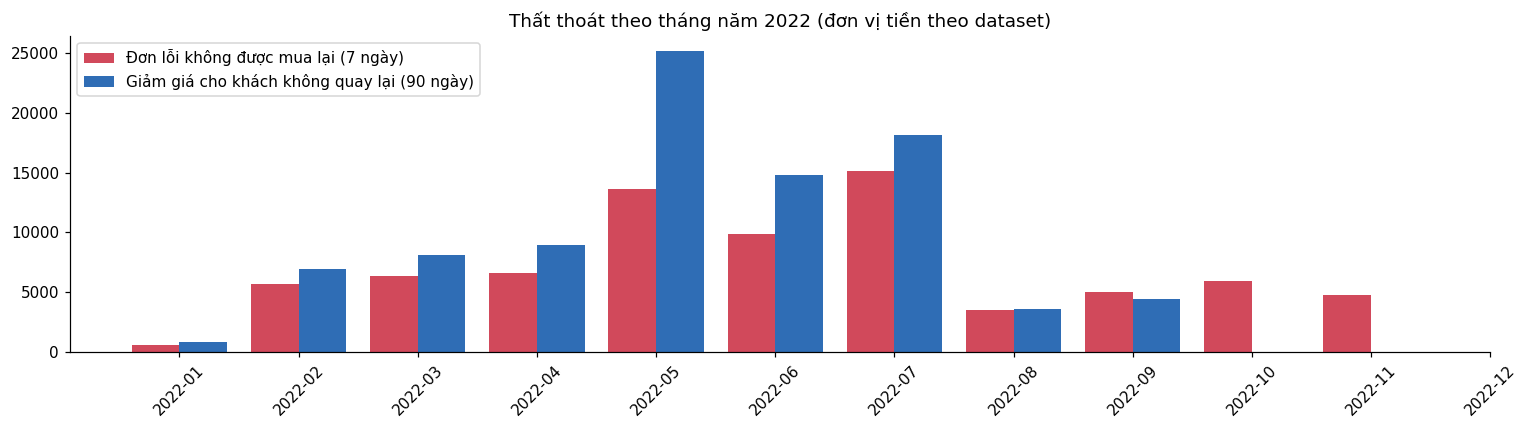

In [14]:
losses = finance.monthly_losses(df).loc["2022-01":"2022-12"]
fig, ax = plt.subplots(figsize=(14, 4))
x = np.arange(len(losses))
ax.bar(x - 0.2, losses["unrecovered_failed_value"], 0.4, color=RED, label="Đơn lỗi không được mua lại (7 ngày)")
ax.bar(x + 0.2, losses["discount_one_time"], 0.4, color=BLUE, label="Giảm giá cho khách không quay lại (90 ngày)")
ax.set_xticks(x, losses.index, rotation=45)
ax.set_title("Thất thoát theo tháng năm 2022 (đơn vị tiền theo dataset)")
ax.legend()
plt.tight_layout()
complete = losses.dropna()
print(f"Các tháng đủ dữ liệu ({complete.index[0]} → {complete.index[-1]}):")
print(f"  Đơn lỗi không được mua lại: {complete['unrecovered_failed_value'].sum():,.0f} "
      f"/ tổng đơn lỗi {complete['failed_value'].sum():,.0f} ({complete['unrecovered_failed_value'].sum() / complete['failed_value'].sum():.1%})")
print(f"  Giảm giá cho khách không quay lại: {complete['discount_one_time'].sum():,.0f} "
      f"/ tổng giảm giá {complete['discount_total'].sum():,.0f} ({complete['discount_one_time'].sum() / complete['discount_total'].sum():.1%})")

## 6. Tất cả chạy tự động mỗi tuần
`python -m src.pipeline` tạo cho mỗi tuần một thư mục `reports/weekly/<tuần>/`:

In [15]:
out_dir, summary = pipeline.run(WEEK)
pd.DataFrame(
    [(p.name, {"brief_leadership.md": "Ban lãnh đạo", "kpis_monthly.csv": "Ban lãnh đạo",
               "brief_marketing.md": "Marketing", "marketing_targets.csv": "Marketing",
               "campaign_effectiveness.csv": "Marketing", "campaign_ids_effectiveness.csv": "Marketing",
               "brief_customer_care.md": "CSKH", "recovery_list.csv": "CSKH",
               "brief_product_it.md": "Product / IT", "product_breakdown.csv": "Product / IT",
               "brief_finance.md": "Tài chính", "finance_monthly_losses.csv": "Tài chính"}.get(p.name, "Chung"))
     for p in sorted(out_dir.iterdir())],
    columns=["file", "phòng ban"],
)

,file,phòng ban
0,brief_customer_care.md,CSKH
1,brief_finance.md,Tài chính
2,brief_leadership.md,Ban lãnh đạo
3,brief_marketing.md,Marketing
4,brief_product_it.md,Product / IT
5,by_department,Chung
6,campaign_effectiveness.csv,Marketing
7,campaign_ids_effectiveness.csv,Marketing
8,finance_monthly_losses.csv,Tài chính
9,kpis_monthly.csv,Ban lãnh đạo


## Tóm tắt — mức độ tin cậy của từng phần

| Phòng ban | Đã làm | Mức độ tin cậy |
|---|---|---|
| Ban lãnh đạo | 14 chỉ số / 6 nhóm KPI theo tháng + bản tin tuần | Cao — tính thẳng từ dữ liệu; chỉ số cần cửa sổ tương lai để `n/a` khi chưa đủ dữ liệu |
| Marketing | Phân nhóm theo slide + điểm quay lại + hiệu quả campaign | Phân nhóm & campaign: cao (mô tả). Điểm quay lại: **vừa phải** (AUC ~0.66) — dùng để ưu tiên |
| CSKH | Danh sách cứu đơn + mẫu tin nhắn theo 7 mã lỗi + cảnh báo | Cao — quy tắc rõ ràng; hiệu quả cứu đơn thực tế cần đo sau triển khai |
| Product / IT | Cảnh báo tuần + khoanh vùng mã lỗi × nền tảng × phương thức | Cao — backtest bắt đúng đợt lỗi 2022; có cảnh báo nhiễu ở nhóm lỗi hiếm |
| Tài chính | Thất thoát do đơn lỗi + giảm giá cho khách một lần | Cao cho phần đo được; là **cận dưới** vì chưa có chi phí quảng cáo / giá trị vòng đời |